# Exercise 2:Random walks

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 2.1
**Compute the following 1D integral via Monte Carlo** 
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$ 
1. **sampling a uniform distribution in $[0,1]$**
2. **using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)**


To sample the integral using the standard mean method, I applied the data blocking technique, implemented with the same `statistics` struct as in Exercise 1, using 100 blocks with 10,000 steps each. At each step, a random value of $x \in [0,1]$ was generated, $f(x)$ was computed, and the sum was incremented. The final estimate is very precise, as shown by the blue curve in the plot below, with error values decreasing from approximately 0.1% to 0.01% from the first to the last block.

This corresponds to sampling the integral $
\int_0^1 f(x) p(x) \, dx
$
with $p(x) = 1$.

The idea of **importance sampling** is that we do not need to impose $p(x) = 1$, but can instead choose a probability distribution that better matches the integrand in order to reduce variance and obtain a more accurate estimate of the integral. Typically, the best results are achieved by sampling from distributions that resemble the integrand.

I tested two possibilities:

- **$p_1(x) = \frac{3}{2}(1-x^2)$**: This parabolic distribution was chosen because its shape resembles the cosine function between 0 and 1. I sampled it using the accept-reject method, since inverting its cumulative distribution would result in a very long and complex expression.

- **$p_2(x) = 1 - \frac{\pi}{2}(x-0.5)$**: This is the normalized first-order expansion of the integrand around the midpoint $x=0.5$. I sampled it using the inverse cumulative method. Although it lacks the overall similarity in shape, it approximates the integrand better than the first case, especially near $x=0$.


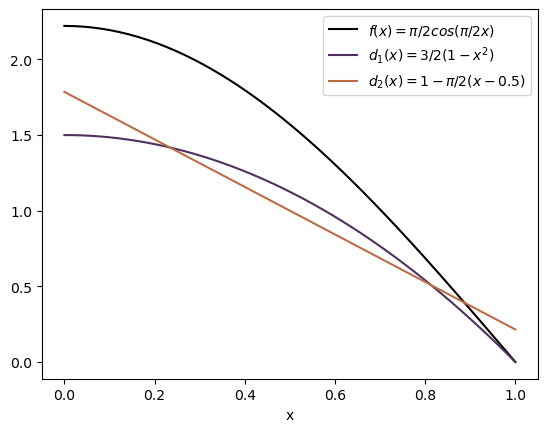

In [65]:
##visualization of the integrand and probability dstributions used for importance sampling
x=np.linspace(0,1)
y=np.pi *0.5*np.sqrt(2)*np.cos(np.pi*0.5*x)
colors =  plt.get_cmap("managua", 10)
y2=3*0.5*(1-x**2)
y1= 1-np.pi*0.5*(x-0.5)

plt.plot(x,y,color='black',label = r'$f(x)=\pi /2 cos(\pi/2 x)$')
plt.plot(x,y2,color=colors(5),label = r'$d_1(x)=3/2(1-x^2)$')
plt.plot(x,y1,color=colors(2),label = r'$d_2(x)=1-\pi /2(x-0.5)$')
plt.legend()
plt.xlabel('x')
plt.show()

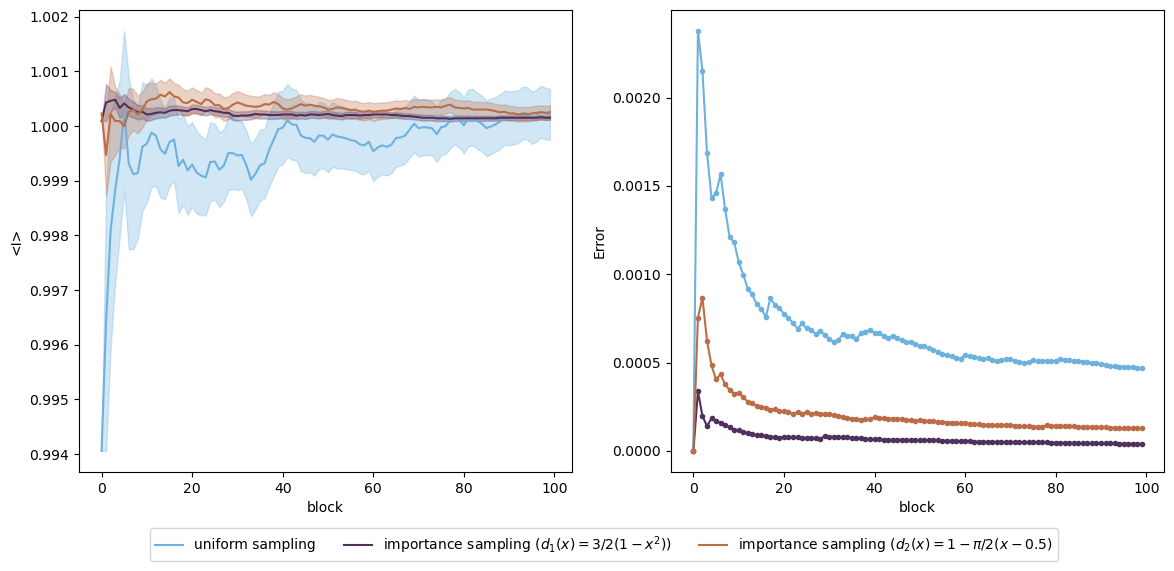

In [66]:
df = pd.read_csv("./OUTPUT/integral_uniform.csv",sep='\t')
df1= pd.read_csv("./OUTPUT/integral_IS_ar.csv",sep='\t')
df2= pd.read_csv("./OUTPUT/integral_IS_inv.csv",sep='\t')
fig,ax = plt.subplots(1,2,figsize=(14,6))


ax[0].plot(df['block'],df['block_ave'],color=colors(8),label='uniform sampling')
ax[0].fill_between(df['block'],df['block_ave']-df['err'],df['block_ave']+df['err'],alpha=0.3,color=colors(8))

ax[0].plot(df1['block'],df1['block_ave'],color=colors(5),label=r'importance sampling ($d_1(x)=3/2(1-x^2)$)')
ax[0].fill_between(df1['block'],df1['block_ave']-df1['err'],df1['block_ave']+df1['err'],alpha=0.3,color=colors(5))

ax[0].plot(df2['block'],df2['block_ave'],color=colors(2),label=r'importance sampling ($d_2(x)=1-\pi /2(x-0.5)$')
ax[0].fill_between(df2['block'],df2['block_ave']-df2['err'],df2['block_ave']+df2['err'],color=colors(2),alpha=0.3)

ax[0].set_xlabel('block')
ax[0].set_ylabel('<I>')

ax[1].plot(df['block'],df['err'],color=colors(8),marker='.')
ax[1].plot(df1['block'],df1['err'],color=colors(5),marker='.')
ax[1].plot(df2['block'],df2['err'],color=colors(2),marker='.')
ax[1].set_xlabel('block')
ax[1].set_ylabel('Error')
fig.legend(
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.05)
)
plt.show()

As expected, using importance sampling significantly improves the integral estimation and reduces the errors significantly. The parabolic trial function is especially effective, since it performs the best in spite of the potential ineffectiveness of the accept-reject method.

## 2.2
**Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D always starting at the origin**
1. **on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$**
2. **in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a **random direction** obtained by sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$**

**Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs</span>, with their statistical uncertainties, as function of the step $i\in [0,10^2]$.**

To simulate a generic random walk, I created a `RandomWalk` class with the following data members:

- **rnd**: a random number generator, which can be initialized with any seed. This ensures that each `RandomWalk` object is independent.
- **position vector**: its dimension can be set during initialization according to the dimensionality of the problem.
- **total number of steps**: the number of steps the random walk will perform.

The class includes functions to set the position, retrieve information, and evolve the walk in different ways. For this exercise, I implemented two types of steps (both with a fixed step length):

- **Lattice step**: the position changes along one of the three axes only.
- **Uniform step**: the position changes in any direction.

An example of the evolution of 10 random walks is shown in the figures on the left.

The main objective was to evaluate the average distance traveled at each step: in order to do so I created a vector of 100 `RandomWalk` objects walks that can evolve simultaneously. This enables the calculation of the mean distance at each step using standard block averaging. 

The results below correspond to a simulation of $10^4$ random walks divided into 100 blocks, allowing the evaluation of the average distance at each of the 100 steps. A fit with the model function $k\sqrt{N}$ is also shown. 

In both cases, the block average follows the model closely, with a value of $k$ close to 1. The last plot shows:

- The difference between the measured average and the model.
- The difference between the two types of evolution.

Although the results are very similar, the lattice random walk shows slightly more diffusive behavior  especially at later steps ($n \approx 100$). This is consistent with the fact that it can only evolve along the three main axes.


In [62]:
from scipy.optimize import curve_fit
def plot_RW_fit(rw_type,f):
    df1 = pd.read_csv(f"./OUTPUT/RW_{rw_type}.csv", sep="\t")
    df2 = pd.read_csv(f"./OUTPUT/{rw_type}_distance.csv", sep="\t")

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(121, projection='3d')

    id_values = df1['walk_id'].unique()
    colors = plt.get_cmap("managua", len(id_values))
    for i in id_values:
        ax1.plot(df1[df1['walk_id']==i]['x'], df1[df1['walk_id']==i]['y'],df1[df1['walk_id']==i]['z'],
                 label=f"Walk {i+1}", color=colors(i))
    
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("z")
    ax1.set_title("10 Random Walks")
    
    
    ax2 = fig.add_subplot(122)
    colors2 = plt.get_cmap("plasma", 4)
    x_vals = np.array(df2['step'])
    par,cov = curve_fit(f,x_vals,df2['block_ave'])
 
    fit = f(x_vals,par)
    ax2.plot(x_vals, f(x_vals,par), '--', label=f'k={par}',color=colors2(0))
    
    ax2.errorbar(df2['step'], df2['block_ave'], yerr=df2['err'],
                 fmt='o', markersize=4, label=r"$\sqrt{<r_N^2>}$",color=colors2(2))
    
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Distance")
    ax2.set_title("Mean Distance")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    return fit



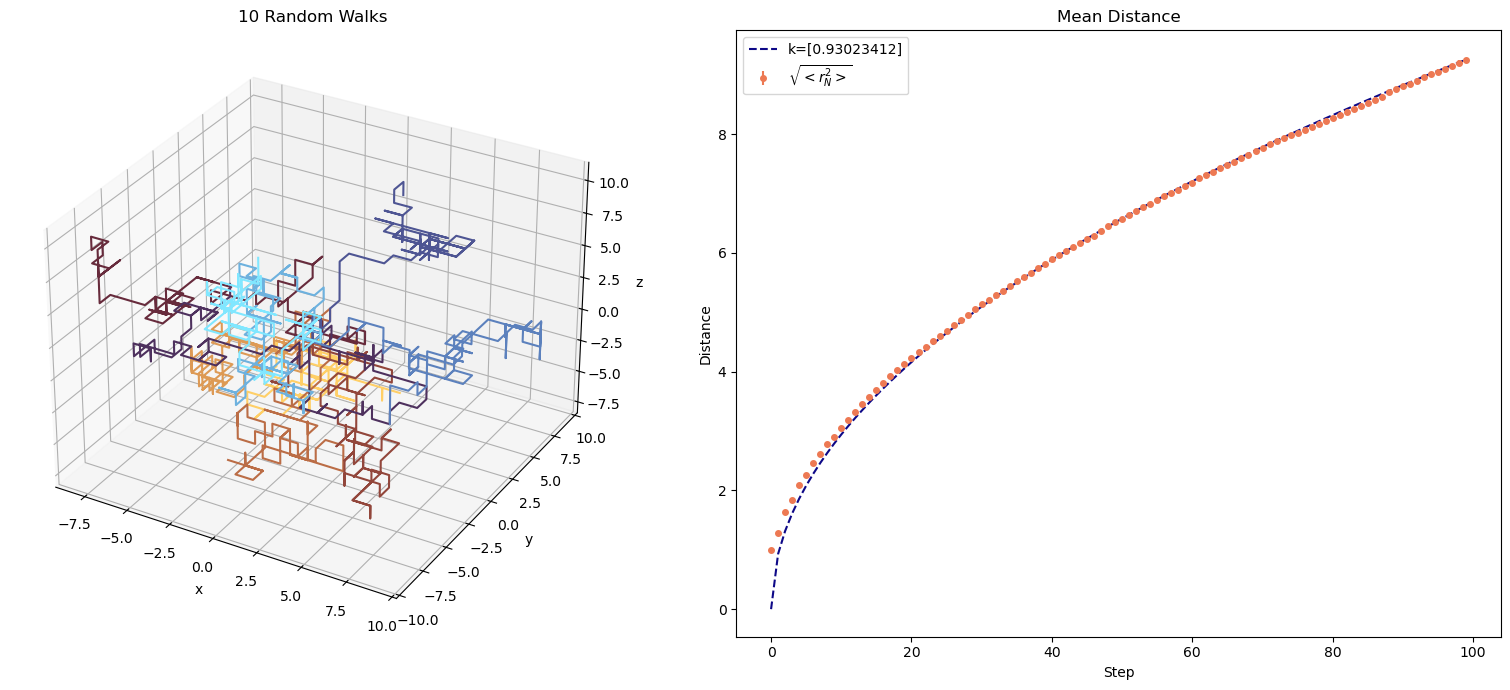

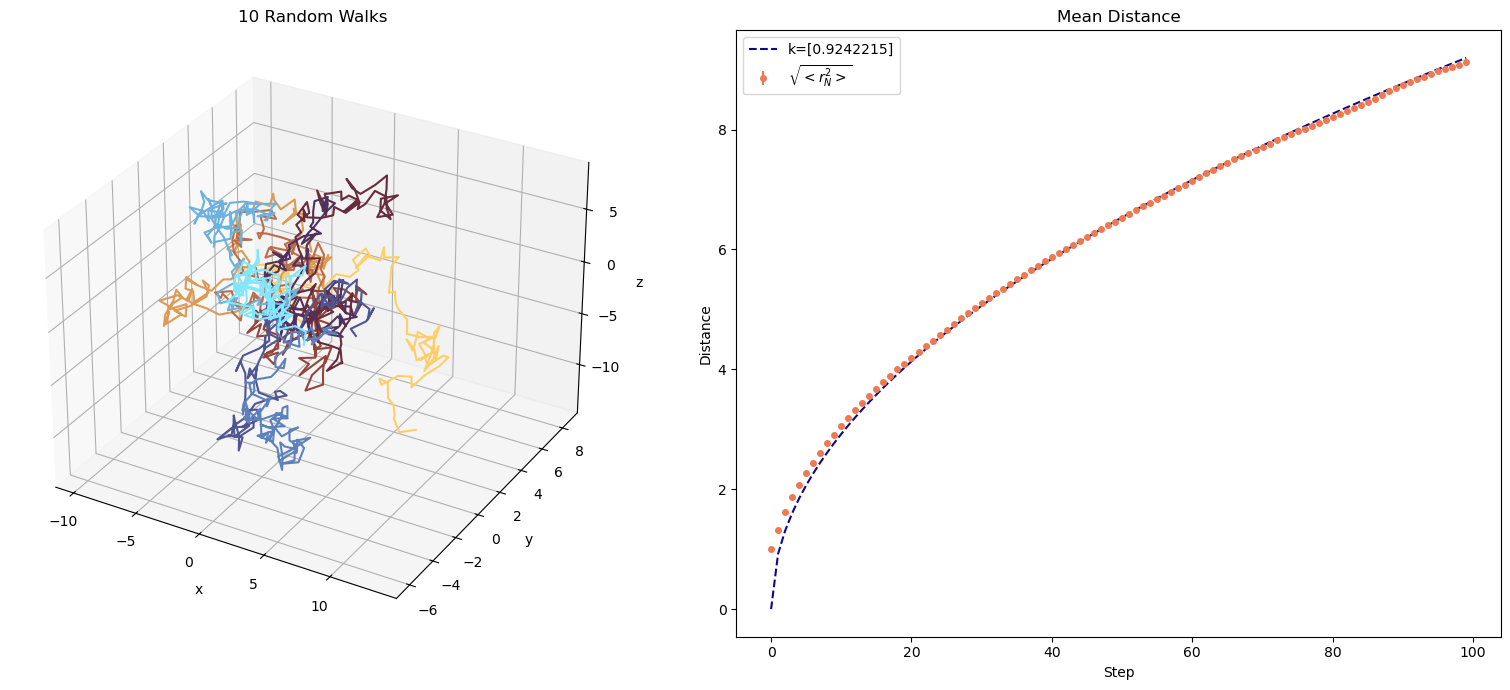

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def model(x,k):
    return k*np.sqrt(x)
fit1=plot_RW_fit('latt',model)
fit2=plot_RW_fit('cont',model)


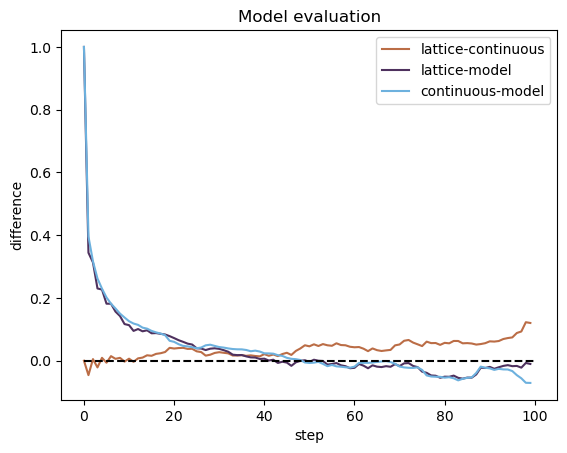

In [64]:
#residuals
dfl = pd.read_csv(f"./OUTPUT/latt_distance.csv", sep="\t")
dfc = pd.read_csv(f"./OUTPUT/cont_distance.csv", sep="\t")
    
x_vals = np.linspace(dfl['step'].min(), dfl['step'].max(), 100)
y_vals = np.sqrt(x_vals)
colors = plt.get_cmap("managua", 10)
plt.plot(dfl['step'],dfl['block_ave']-dfc['block_ave'],label='lattice-continuous',color=colors(2))
plt.plot(dfl['step'],dfl['block_ave']-fit1,label='lattice-model',color=colors(5))
plt.plot(dfc['step'],dfc['block_ave']-fit2,label='continuous-model',color=colors(8))
plt.hlines(0,0,100,color='black',linestyle='dashed')
plt.legend()
plt.title('Model evaluation')
plt.xlabel('step')
plt.ylabel('difference')
plt.show()